

#  Train YOLOv8 Object Detection

---



**Let's begin!**

## Before you start

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `GPU`, and then click `Save`.

In [ ]:
!nvidia-smi

Tue Apr 14 16:16:32 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.95.05              Driver Version: 580.95.05      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H200                    On  |   00000000:59:00.0 Off |                    0 |
| N/A   33C    P0             75W /  700W |       0MiB / 143771MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
import os
HOME = os.getcwd()
print(HOME)

/root


## Install YOLOv8

YOLOv8 can be installed in two ways - from the source and via pip. This is because it is the first iteration of YOLO to have an official package.

In [ ]:
# Pip install method (recommended)

%uv pip install ultralytics==8.2.103 -q

from IPython import display
display.clear_output()

# prevent ultralytics from tracking your activity
!yolo settings sync=False

import ultralytics
ultralytics.checks()

Ultralytics YOLOv8.2.103 🚀 Python-3.12.6 torch-2.8.0+cu129 CUDA:0 (NVIDIA H200, 143156MiB)
Setup complete ✅ (86 CPUs, 1999.8 GB RAM, 0.3/512.0 GB disk)


In [ ]:
from ultralytics import YOLO

from IPython.display import display, Image

#Upload Dataset

In [ ]:
!mkdir -p {HOME}/datasets
%cd {HOME}/datasets

%uv pip install roboflow -q

from roboflow import Roboflow
rf = Roboflow(api_key="i1lKMzpVVzhVPfmu1Joy")
project = rf.workspace("tahanis-workspace").project("nemo-3zv5f")
version = project.version(1)
dataset = version.download("yolov8")



/root/datasets
Note: you may need to restart the kernel to use updated packages.
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to frout-dataset-2-1 in yolov8:: 100%|██| 12445/12445 [00:03<00:00, 3651.09it/s]


## Custom Data model Training

In [ ]:
%cd {HOME}

!yolo task=detect mode=train model=yolov8s.pt data={dataset.location}/data.yaml epochs=100 imgsz=800 plots=True patience=10

/root
100%|██████████████████████████████████████| 21.5M/21.5M [00:00<00:00, 82.8MB/s]
New https://pypi.org/project/ultralytics/8.4.37 available 😃 Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.2.103 🚀 Python-3.12.6 torch-2.8.0+cu129 CUDA:0 (NVIDIA H200, 143156MiB)
engine/trainer: task=detect, mode=train, model=yolov8s.pt, data=/root/datasets/frout-dataset-2-1/data.yaml, epochs=100, time=None, patience=10, batch=16, imgsz=800, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=

/root


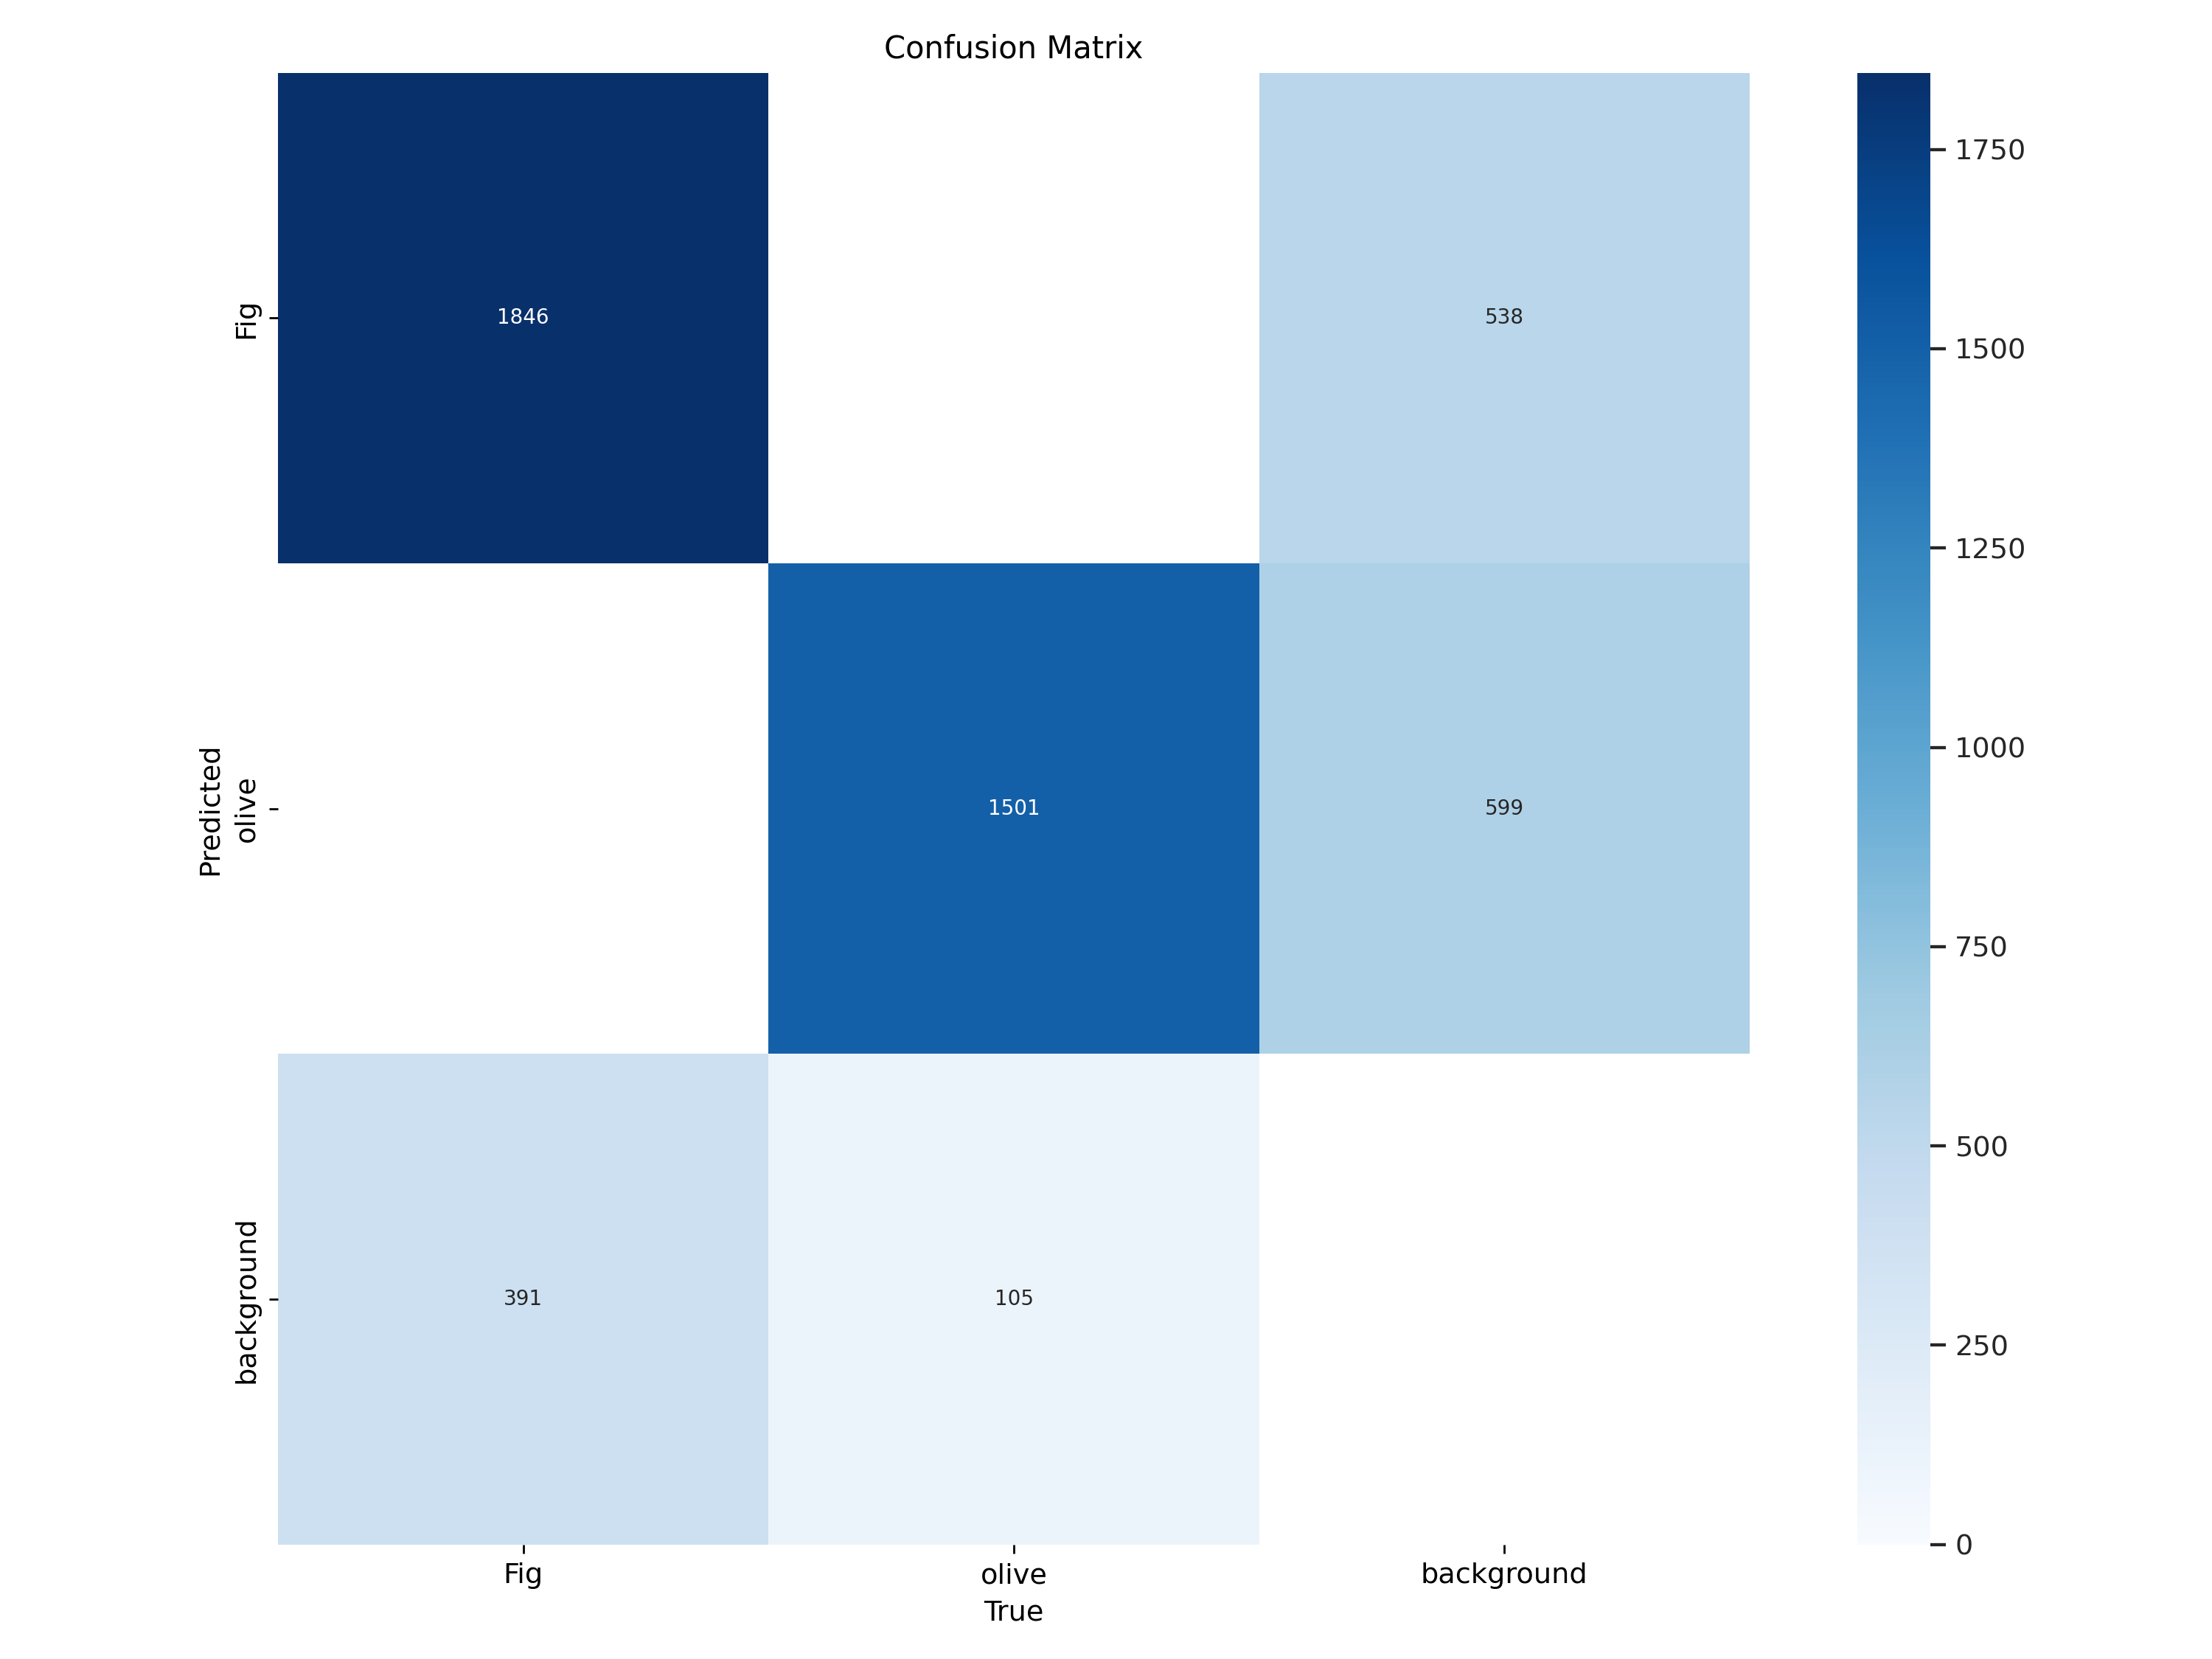

In [ ]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train/confusion_matrix.png', width=600)

/root


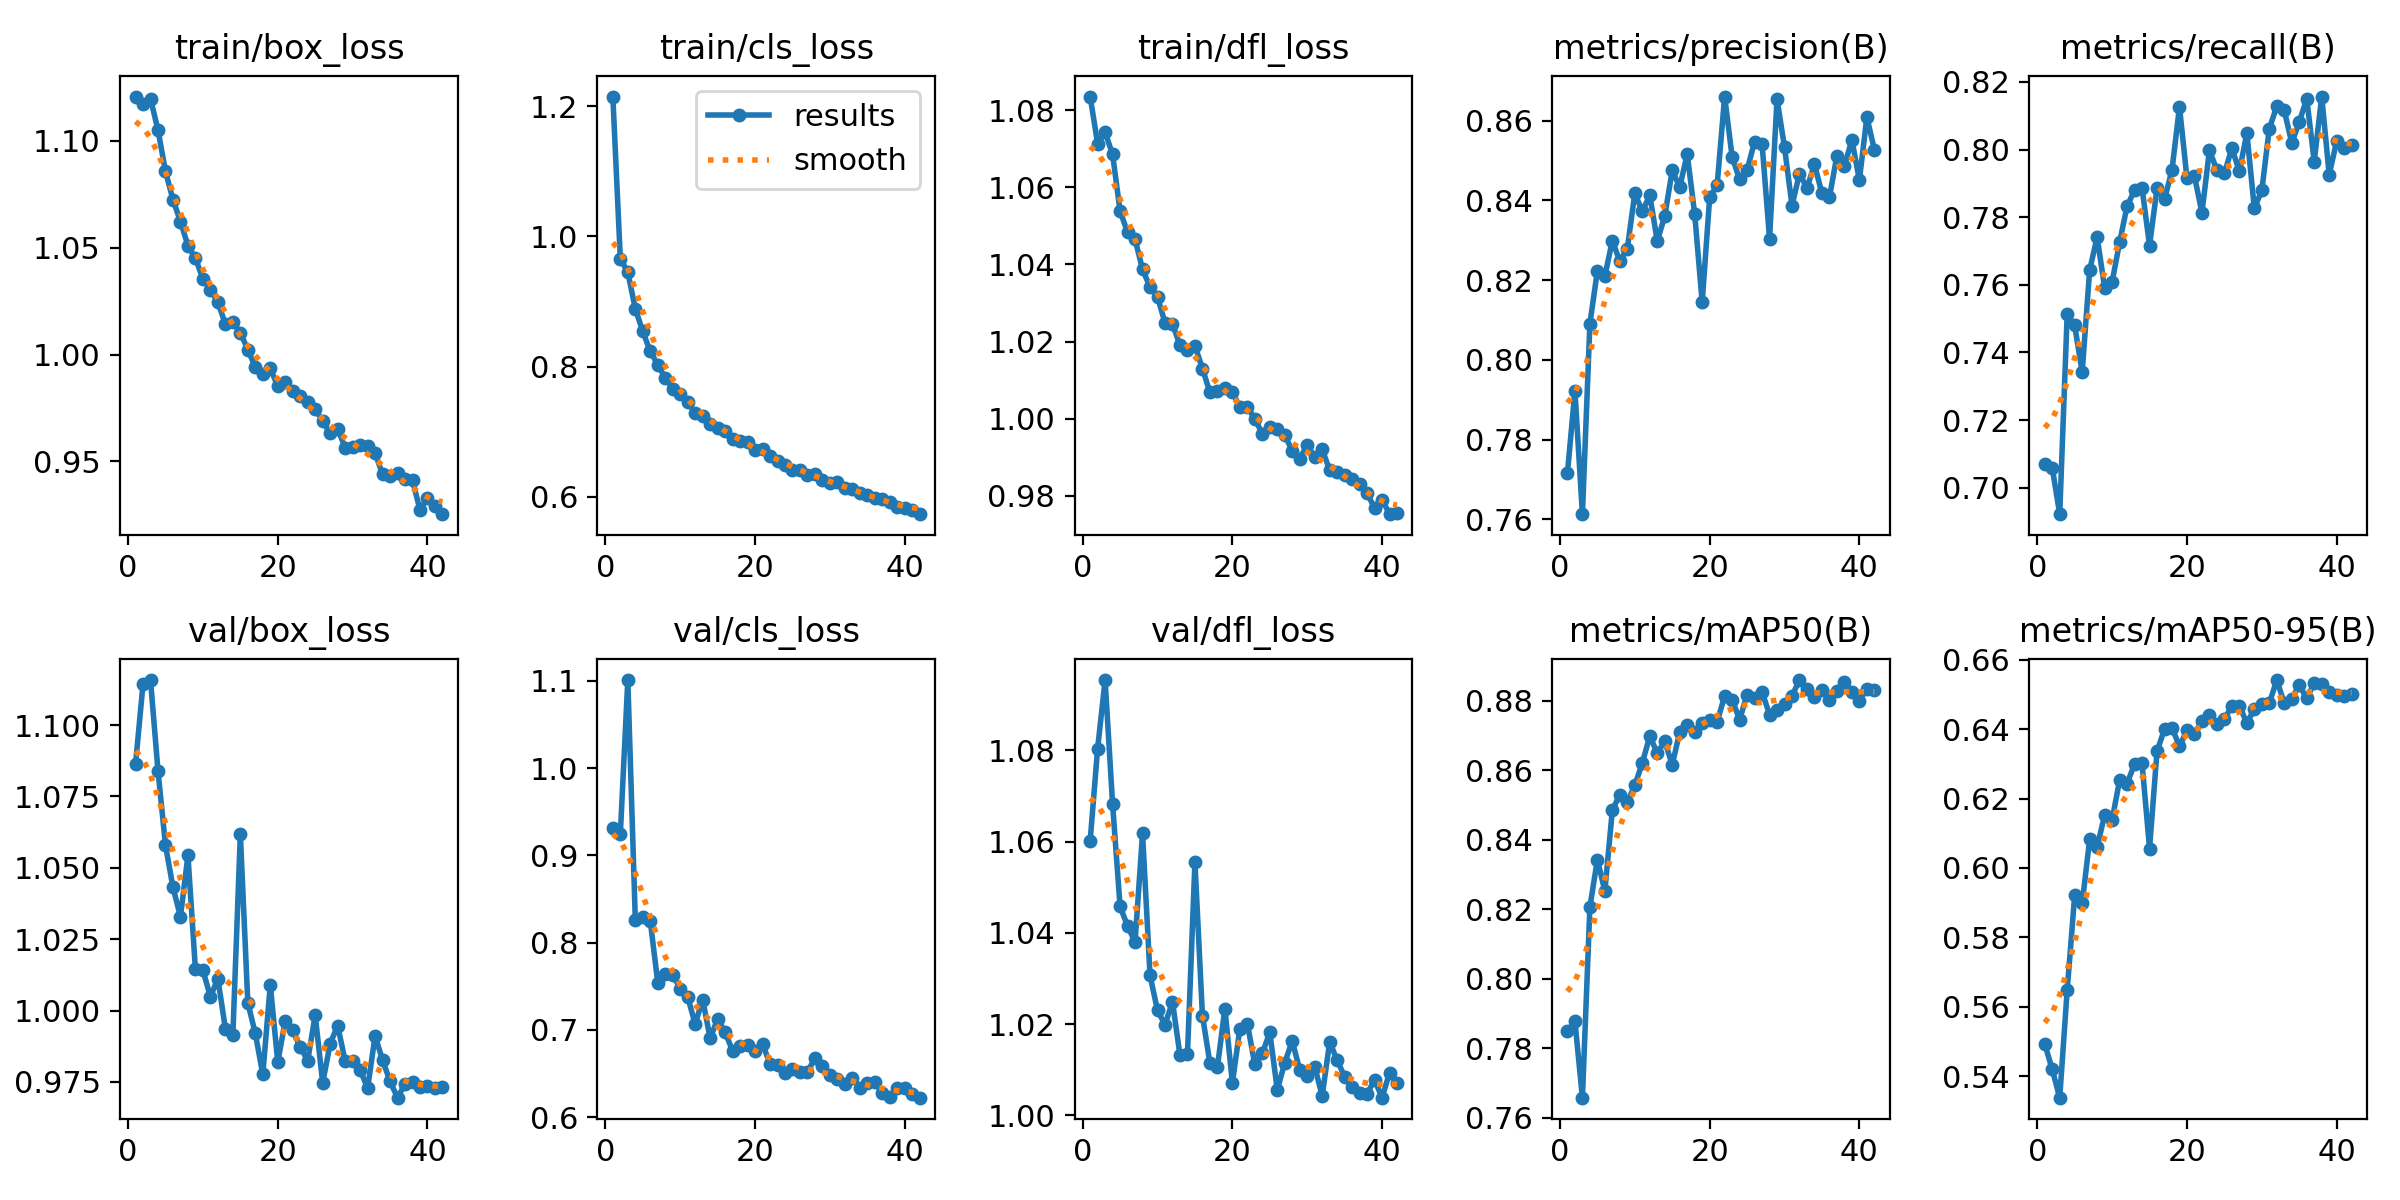

In [ ]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train/results.png', width=600)

/root


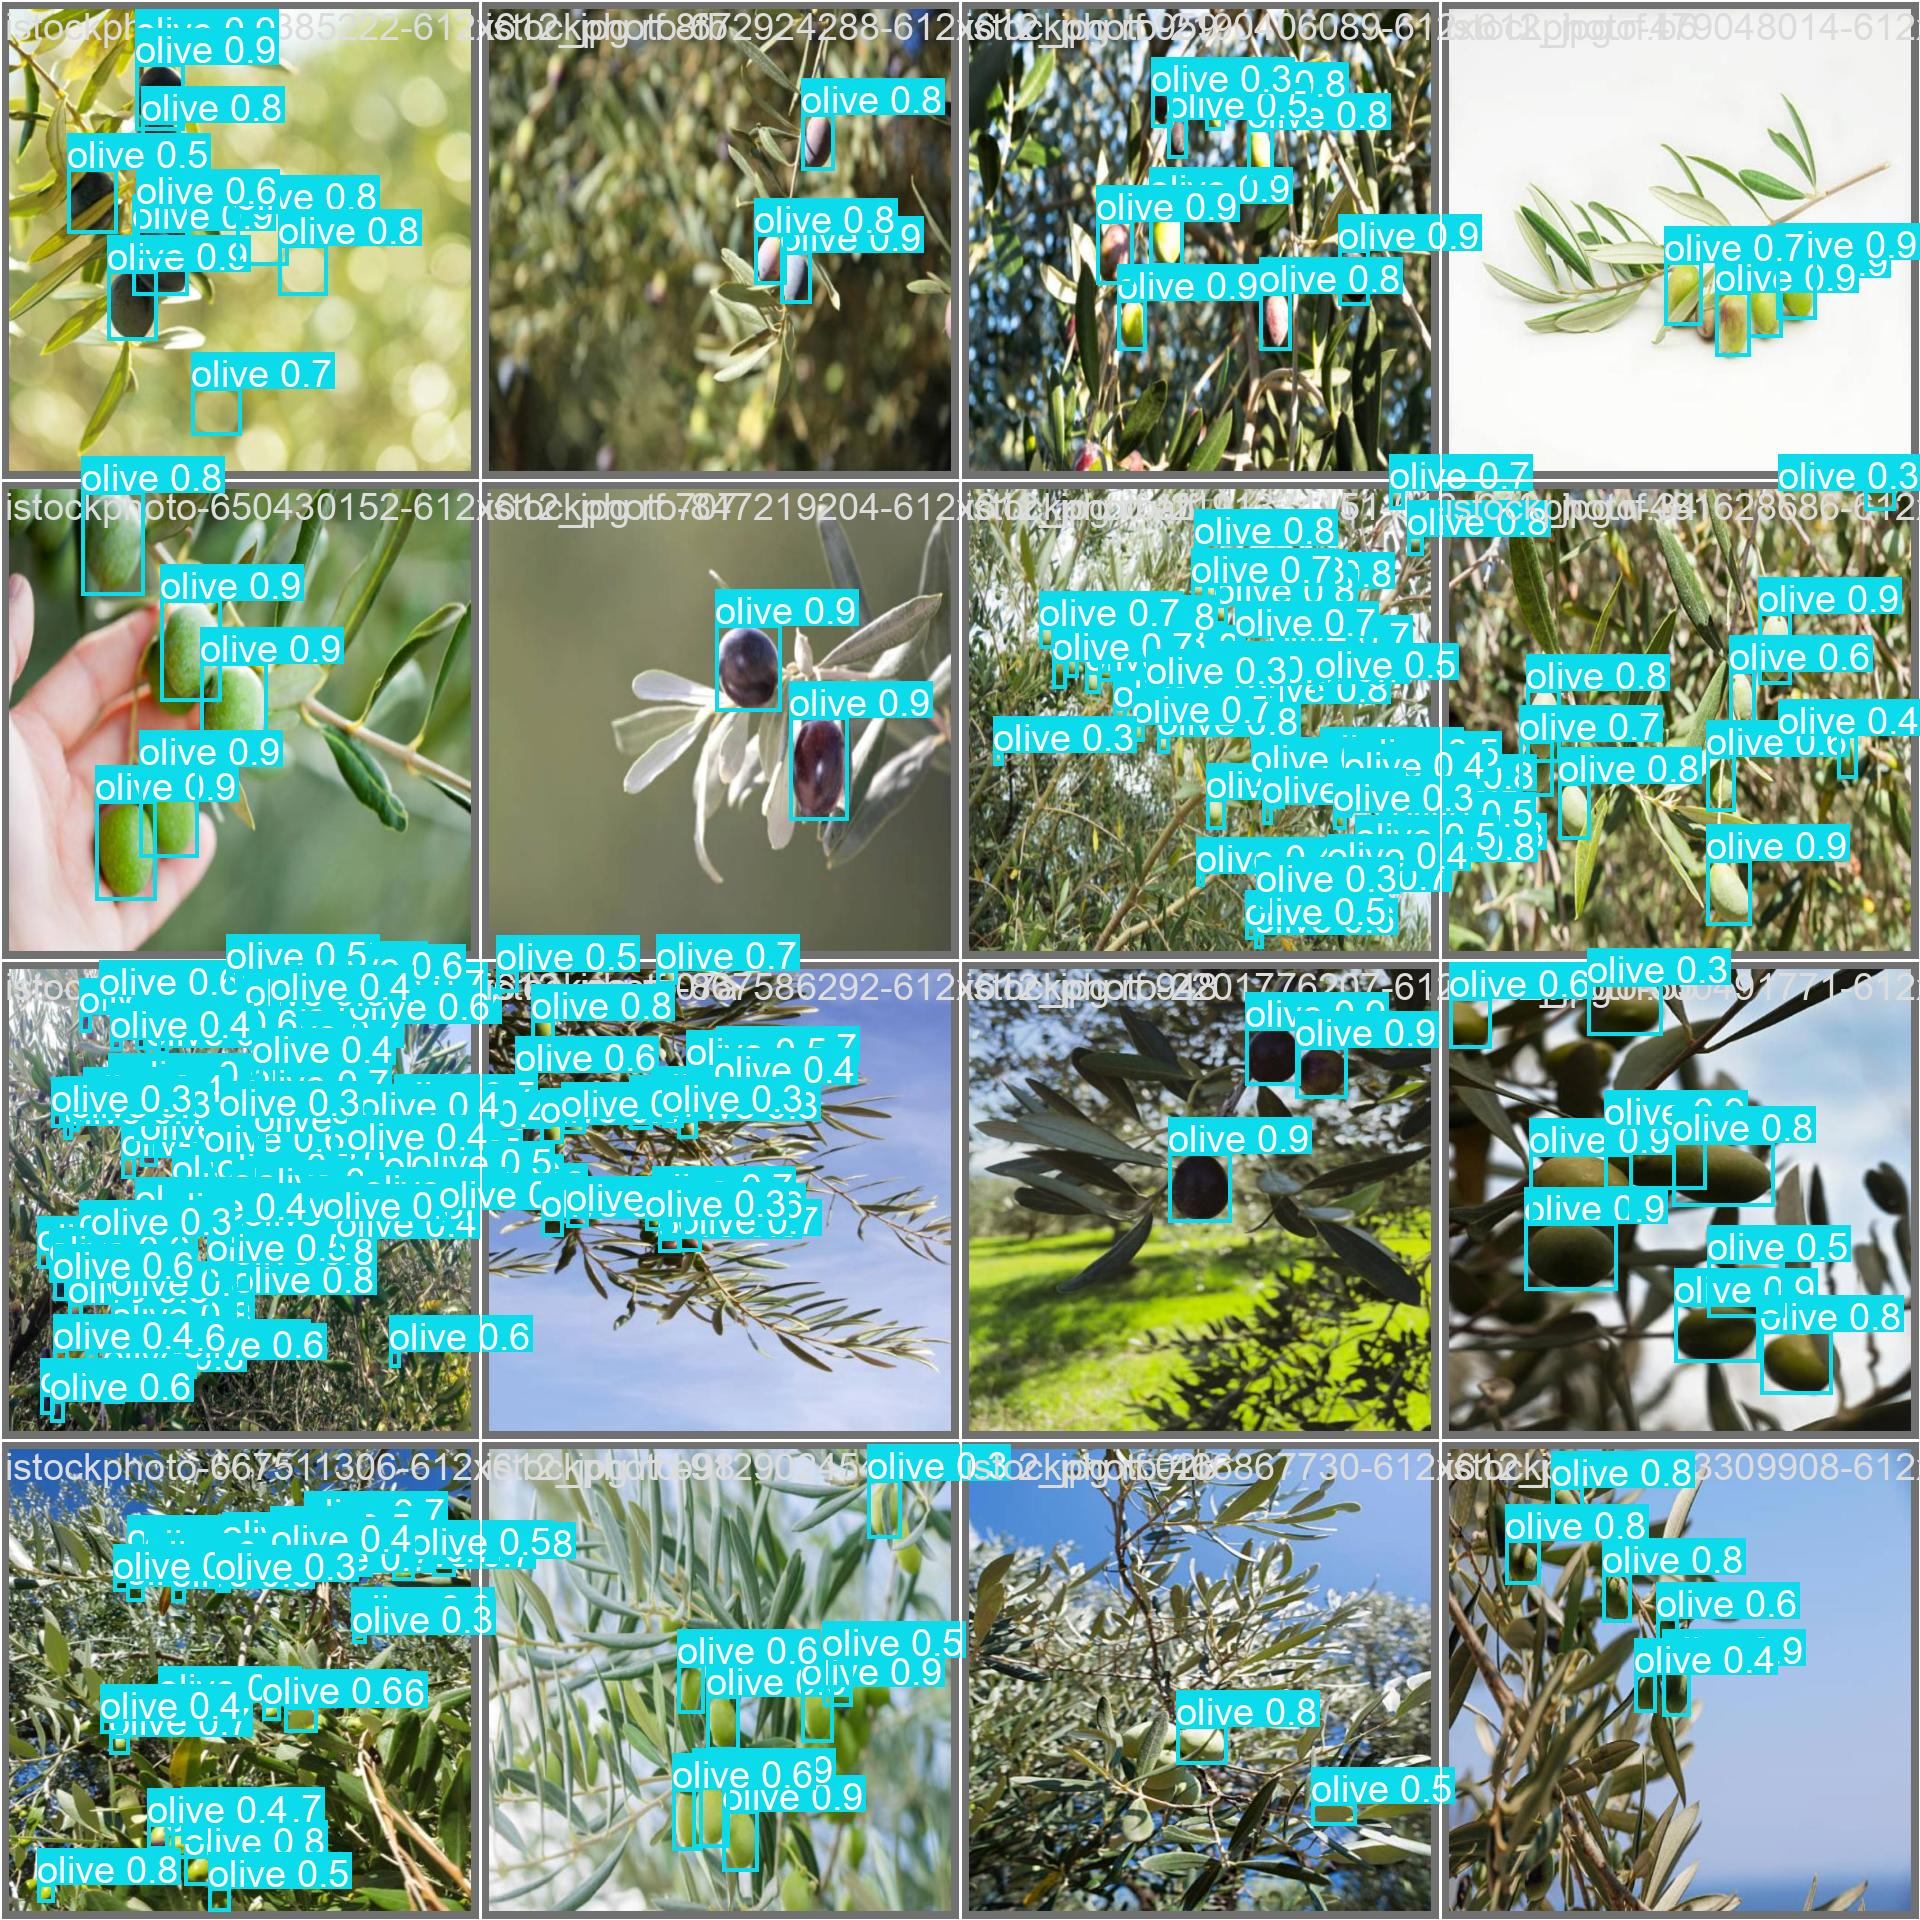

In [ ]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train/val_batch0_pred.jpg', width=600)

## Validate Custom Model

In [ ]:
%cd {HOME}

!yolo task=detect mode=val model={HOME}/runs/detect/train/weights/best.pt data={dataset.location}/data.yaml

/root
Ultralytics YOLOv8.2.103 🚀 Python-3.12.6 torch-2.8.0+cu129 CUDA:0 (NVIDIA H200, 143156MiB)
Model summary (fused): 168 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs
val: Scanning /root/datasets/frout-dataset-2-1/valid/labels.cache... 389 images,
                 Class     Images  Instances      Box(P          R      mAP50  m
                   all        389       3843      0.847      0.813      0.886      0.655
                   Fig        237       2237      0.894      0.758      0.865       0.65
                 olive        152       1606        0.8      0.867      0.907       0.66
Speed: 1.0ms preprocess, 4.8ms inference, 0.0ms loss, 1.5ms postprocess per image
Results saved to runs/detect/val
💡 Learn more at https://docs.ultralytics.com/modes/val


## 🏆 DONE





